In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

data = pd.read_csv(r"C:\Users\tsiakiris\OneDrive - MTC\MT\Final_Combined_Processed.csv")
# X = data.drop(["Soil_Moisture", "Unnamed: 0", "Latitude", "Longitude"], axis=1)   # predictors
X = data.drop(["Soil_Moisture", "Unnamed: 0"], axis=1)   # predictors
y = data["Soil_Moisture"]# target

### Model Training and Finetuning of parameters

In [4]:
# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model
model = RandomForestRegressor(random_state=42)

# 4. Parameter Grid
param_grid = {
    'n_estimators': [100,300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']}

# 5. K-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 6. Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',   # or 'r2'
    n_jobs=-1,
    verbose=1)

# 7. Fit
grid_search.fit(X_train, y_train)

# 8. Best Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score: -0.0014815450580794548


Using scoring='r2' & param_grid = {'n_estimators': [100, 300], 'max_depth': [10, 20], 'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.7345893384098793

### Calculate the metrics for Training and Testing

In [5]:
best_model = grid_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics function
def calculate_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }

# Calculate metrics
train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

# Create table
metrics_table = pd.DataFrame({
    "Training Set": train_metrics,
    "Test Set": test_metrics
})

print(metrics_table)

      Training Set  Test Set
RMSE      0.022260  0.038082
MAE       0.015246  0.026582
R²        0.934663  0.809311


### Create plots of the model

#### Feature importance

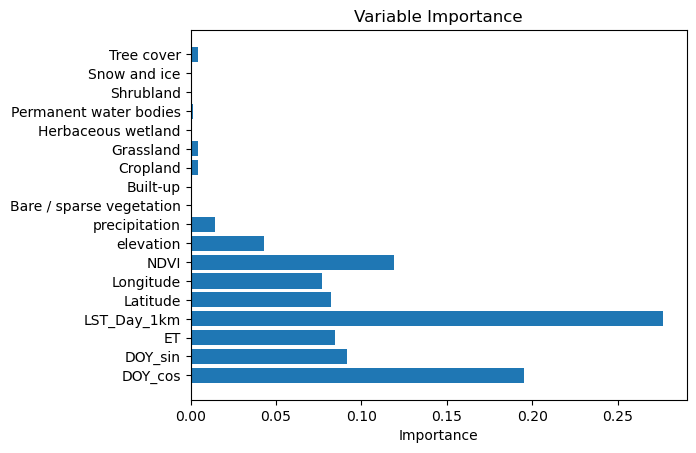

In [6]:
importance = best_model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Variable Importance")
plt.show()

#### Observed vs. Predicted (test)

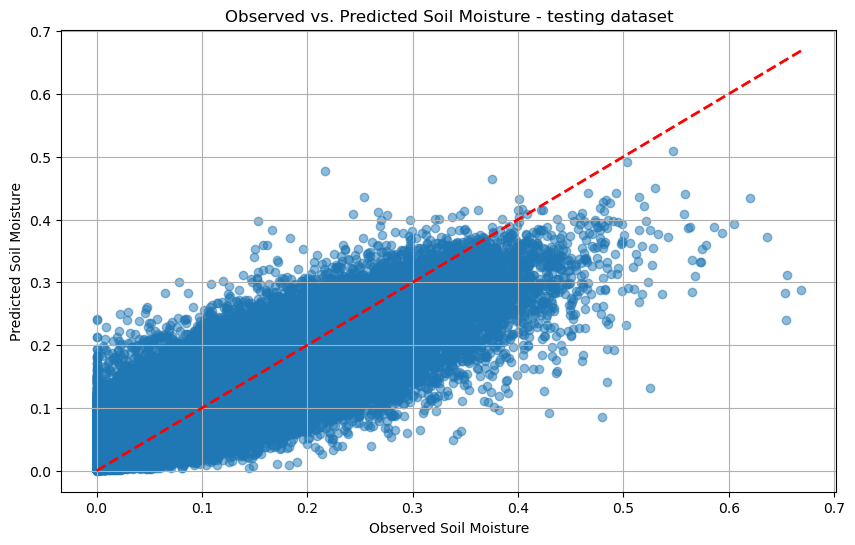

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Observed Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Observed vs. Predicted Soil Moisture - testing dataset")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a perfect prediction line
plt.grid(True)
plt.show()

#### Residuals plot (test)

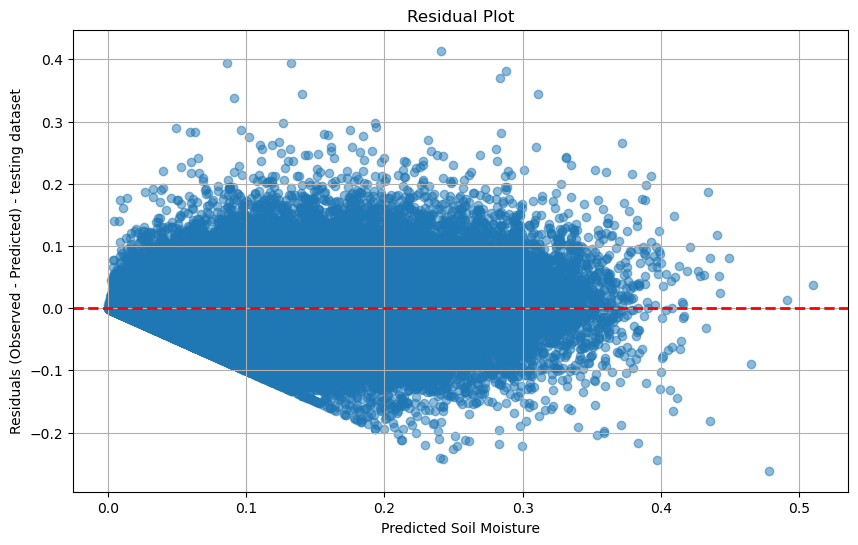

In [8]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Add a horizontal line at y=0
plt.xlabel("Predicted Soil Moisture")
plt.ylabel("Residuals (Observed - Predicted) - testing dataset")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

#### Observed vs. Predicted (train)

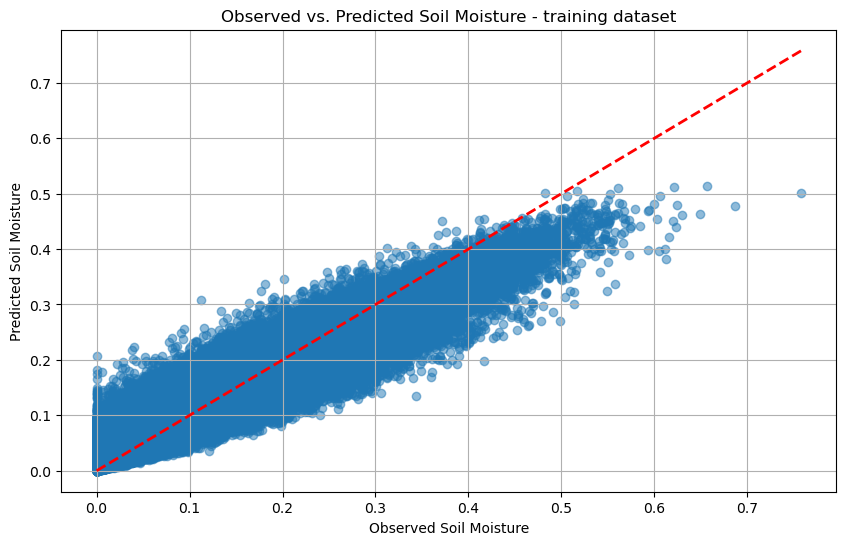

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.xlabel("Observed Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Observed vs. Predicted Soil Moisture - training dataset")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Add a perfect prediction line
plt.grid(True)
plt.show()

#### Residuals plot (train)

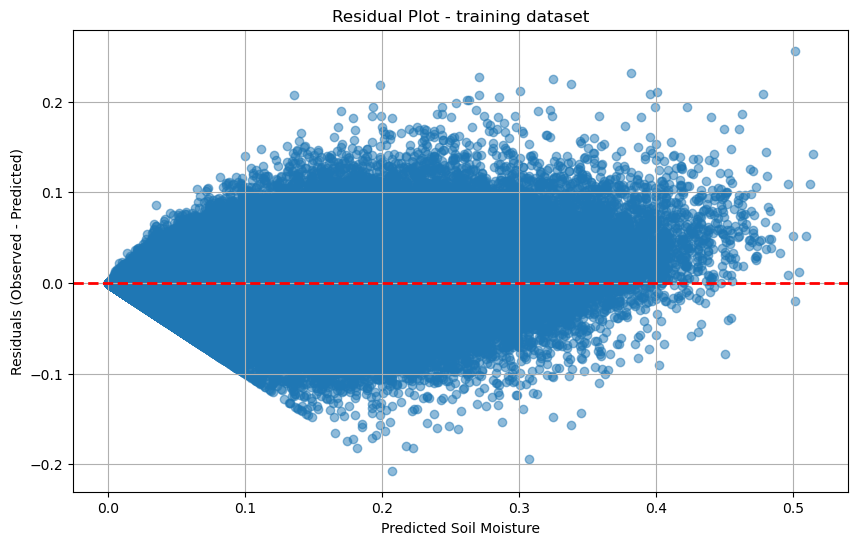

In [10]:
residuals = y_train - y_train_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_train_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Add a horizontal line at y=0
plt.xlabel("Predicted Soil Moisture")
plt.ylabel("Residuals (Observed - Predicted)")
plt.title("Residual Plot - training dataset")
plt.grid(True)
plt.show()

### Export the model

In [11]:
joblib.dump(best_model, r"C:\Users\tsiakiris\OneDrive - MTC\MT\random_forest_model_optimal_20260520.pkl")

['C:\\Users\\tsiakiris\\OneDrive - MTC\\MT\\random_forest_model_optimal_20260520.pkl']